# NetColoc analysis of a single trait/species - here example of Obsessive-compulsive disorder (OCD) in human

Example to demonstrate NetColoc workflow from single gene set





# _Obtain input gene sets and interactome_

## 1. Load required packages

In [1]:
# load required packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd
import re
import random

from IPython.display import display

import getpass
import ndex2

import json
import cdapsutil

from gprofiler import GProfiler
gp = GProfiler("MyToolName/0.1")

from scipy.stats import hypergeom
from scipy.stats import norm

# latex rendering of text in graphs
import matplotlib as mpl
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

sns.set(font_scale=1.4)

sns.set_style('white')

sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.rcParams['svg.fonttype'] = 'none'

from datetime import datetime
import sys
%matplotlib inline

In [2]:
# verify DDOT was installed
import ddot

from netcoloc import netprop_zscore, netprop, network_colocalization, validation


## 2. Select one gene set of interest. Load gene set from text files into python.


Identify one gene sets of interest. Gene sets should come from experimental data (not manual curation) to avoid bias. 

**Usage Note**: gene sets should be < 500 genes (propagation algorithm breaks down if seeded with larger sets). If your gene set is larger, only use the top 500 as seeds to the network propagation.



In [3]:
# set names of geneset 1
# ------ customize this section based on your gene sets and how they should be labeled -------
d1_name='OCD'


In [4]:
# ------ customize this section based your input genesets -------

# load 
D1_df = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/data/OCDgenes_v4.txt')
D1_df.index = D1_df['gene']
print('Number of '+d1_name+' genes:', len(D1_df))
D1_genes = D1_df.index.tolist() # define rare variant genes to seed network propagation
print("First 5 genes:", D1_genes[0:5])

Number of OCD genes: 48
First 5 genes: ['MAIP1', 'CELSR3', 'NCKIPSD', 'ARIH2', 'P4HTM']


## 3. Select gene interaction network to use for the analysis.

Identify network UUID on NDEx (ndexbio.org) and use this to import to this Jupyter notebook. We recommend using PCNet as a starting point, but a user may want to switch to “STRING high confidence” if using a machine with low memory (< 8GB RAM).


In [5]:
# interactome_uuid='4de852d9-9908-11e9-bcaf-0ac135e8bacf' # for PCNet
#interactome_uuid='275bd84e-3d18-11e8-a935-0ac135e8bacf' # for STRING high confidence
interactome_uuid='d73d6357-e87b-11ee-9621-005056ae23aa' # for PCNet2.0 Number of nodes: 19267 / Number of edges: 3852119
ndex_server='public.ndexbio.org'
ndex_user=None
ndex_password=None
G_int = ndex2.create_nice_cx_from_server(
            ndex_server, 
            username=ndex_user, 
            password=ndex_password, 
            uuid=interactome_uuid
        ).to_networkx()
nodes = list(G_int.nodes)

# remove self edges from network
G_int.remove_edges_from(nx.selfloop_edges(G_int))

# print out the numbers of nodes and edges in the interatome for diagnostic purposes:
print('Number of nodes:', len(G_int.nodes))
print('\nNumber of edges:', len(G_int.edges))

Number of nodes: 19267

Number of edges: 3852119


In [6]:
int_nodes = list(G_int.nodes)

# _Identify network colocalized gene network_

## 4. Precalculate matrices needed for propagation. This step should take a few minutes (more for larger/denser networks) 

A benchmarking analysis demonstrates that the runtime required scales with the number of edges (w’) and the number of nodes (w’’). NetColoc includes functionality for saving and loading these matrices, by setting the XXX parameter, which can be useful if running multiple analyses. The diffusion parameter, which controls the rate of propagation through the network, may be set in this step. In practice, we have found that results are not dependent on the choice of this parameter, and recommend using the default value of 0.5.

Background on network propagation: https://www.nature.com/articles/nrg.2017.38.pdf?origin=ppub


In [7]:
# pre-calculate matrices used for network propagation. this step takes a few minutes, more for denser interactomes
#print('\ncalculating w_prime')
#w_prime = netprop.get_normalized_adjacency_matrix(G_int, conserve_heat=True)

#print('\ncalculating w_double_prime')
#w_double_prime = netprop.get_individual_heats_matrix(w_prime, .5)

# w_double_prime can be saved to the file netcoloc_w_double_prime.npy
# in current working directory with the following call:
#
# np.save('netcoloc_w_double_prime.npy', w_double_prime)

# and reloaded later with:
# w_double_prime = np.load('netcoloc_w_double_prime.npy')
#
# NOTE: Saving w_double_prime results in a several gigabyte file and
#       takes a minute or more to save and load


In [7]:
# pre-calculate matrices used for network propagation. this step takes a few minutes, more for denser interactomes
#print('\ncalculating w_prime')
#w_prime = netprop.get_normalized_adjacency_matrix(G_int, conserve_heat=True)

##print('\ncalculating w_double_prime')
#w_double_prime = netprop.get_individual_heats_matrix(w_prime, .5)

#w_double_prime can be saved to the file netcoloc_w_double_prime.npy
# in current working directory with the following call:
#np.save('netcoloc_w_double_prime_OCDext-noMHC_CCDv12.npy', w_double_prime)
#np.save('netcoloc_w_prime_OCDext-noMHC_CCDv12.npy', w_prime)

# and reloaded later with: SEEMS TO BE THE SAME FOR ALL, NOT INPUT GENE SPECIFIC
#print('\nload_saved_w_double_prime')
#w_double_prime = np.load('netcoloc_w_double_prime_OCDext-noMHC_CCDv12.npy')

###load the ones created in CrossSpecies instead:

w_double_prime = np.load('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Notebooks/indiv_heats_OCDv4_CCDsept25.npy')
w_prime = np.load('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Notebooks/w_prime_OCDv4_CCDsept25.npy')

# NOTE: Saving w_double_prime results in a several gigabyte file and
#       takes a minute or more to save and load

## 5. Subset seed genes to those found in the selected network. 

Only genes contained in the interaction network will be retained for downstream analysis. 


In [8]:
# subset seed genes to those found in interactome
print("Number of D1 genes:", len(D1_genes))
D1_genes = list(np.intersect1d(D1_genes,int_nodes))
print("Number of D1 genes in interactome:", len(D1_genes))

Number of D1 genes: 48
Number of D1 genes in interactome: 48


## 6. Compute network proximity scores from seed gene set.

The network proximity scores include a correction for the degree distribution of the input gene sets. The runtime required for computing the network proximity scores increases linearly with the number of nodes in the underlying interaction network and with the size of the input gene list

In [10]:
# D1 network propagation
print('\nCalculating D1 z-scores: ')
z_D1, Fnew_D1, Fnew_rand_D1 = netprop_zscore.calculate_heat_zscores(w_double_prime, int_nodes, 
                                                                    dict(G_int.degree), 
                                                                    D1_genes, num_reps=1000,
                                                                    minimum_bin_size=100)

z_D1 = pd.DataFrame({'z':z_D1})

z_D1.sort_values('z',ascending=False).head()


Calculating D1 z-scores: 


,z
KDM6B,10.991122
ASXL3,10.905475
TRAF7,10.895410
KMT2E,10.783263
DIP2A,10.639522


In [9]:
## D1 load network z-scores: NO NEED TO RECALCULATE
z_D1 = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/z_D1_OCD_z-scores_pcnet2_251022.csv', sep =",", index_col=0)
z_D1.sort_values('z',ascending=False).head()

,z
TUBB,22.379769
PABPC1L,21.400359
FLOT1,19.031443
ATP5MC1,18.392037
MAIP1,17.415480


## 7. Build proximal subnetwork by taking z> thresh 

Select genes which have z>threshold (default = 3). These genes are proximal in network space to the seed gene set

In [10]:
# ----------- select thresholds for NetColoc -----------------
zthresh=3 # default = 3

# select the genes in the network intersection, make a subgraph

G_prox = nx.subgraph(G_int,z_D1[z_D1['z']>zthresh].index.tolist()) 
print("Nodes in proximal subgraph:", len(G_prox.nodes()))
print("Edges in proximal subgraph:", len(G_prox.edges()))

Nodes in proximal subgraph: 361
Edges in proximal subgraph: 2019


## 8. Transform NetColoc proximal subnetwork edges to cosine similarities (OPTIONAL)

Transform NetColoc subnetwork edges to cosine similarities, with the function ‘network_colocalization.transform_edges’. The cosine similarity score between two genes represents the extent to which those genes have similar interactors. In practice, the cosine similarity transformed score helps to visually reveal the underlying clustering structure present in a network. 



In [11]:
G_cosSim=network_colocalization.transform_edges(G_prox,method='cosine_sim',edge_weight_threshold=0.95)

# _Compute systems map from proximal subgraph_

## 9. Convert network colocalization subnetwork to form used in community detection module

In [12]:
# compile dataframe of metadata for overlapping nodes
node_df = pd.DataFrame(index=list(G_prox.nodes))
node_df = node_df.assign(d1_seeds=0, d1_name=d1_name,)
node_df.loc[list(np.intersect1d(D1_genes,node_df.index.tolist())), 'd1_seeds']=1
node_df['z_d1']=z_D1.loc[list(G_prox.nodes)]['z']
node_df['sum_seeds']=node_df['d1_seeds']

node_df = node_df.sort_values('z_d1',ascending=False)
node_df.head(15)

,d1_seeds,d1_name,z_d1,sum_seeds
TUBB,1,OCD,22.379769,1
PABPC1L,1,OCD,21.400359,1
FLOT1,1,OCD,19.031443,1
ATP5MC1,1,OCD,18.392037,1
MAIP1,1,OCD,17.415480,1
ZNF804B,1,OCD,17.066451,1
CLP1,1,OCD,16.263568,1
YWHAB,1,OCD,15.575245,1
H4C11,1,OCD,15.291991,1
CTNND1,1,OCD,14.560155,1


## 10. Run community detection on NetColoc subnetwork (recommend HiDef).

Documentation for CDAPS utils to build multiscale systems map in notebook

https://cdapsutil.readthedocs.io/en/latest/quicktutorial.html#example  
https://cdapsutil.readthedocs.io/en/latest/cdapsutil.html#community-detection  

In [13]:
print("Nodes in overlap subgraph:", len(G_prox.nodes()))
print("Edges in overlap subgraph:", len(G_prox.edges()))
# Create cx format of overlap subgraph
G_prox_cx = ndex2.create_nice_cx_from_networkx(G_prox)
G_prox_cx.set_name(d1_name+'_NetColoc_subgraph') 
for node_id, node in G_prox_cx.get_nodes():
    data = node_df.loc[node['n']]
    for row, value in data.items():
        if row == 'd1_seeds' or row == 'd2_seeds' or row=='sum_seeds':
            data_type = 'double'
        elif row=='d1_name' or row=='d2_name':
            data_type='string'
        else:
            data_type = 'double'
        G_prox_cx.set_node_attribute(node_id, row, value, type=data_type)

cd = cdapsutil.CommunityDetection()

# Run HiDeF on CDAPS REST service
G_hier = cd.run_community_detection(G_prox_cx, algorithm='hidefv1.1beta',arguments={'--maxres':'20'})

Nodes in overlap subgraph: 361
Edges in overlap subgraph: 2019


In [14]:
# Print information about hierarchy
print('Hierarchy name: ' + str(G_hier.get_name()))
print('# nodes: ' + str(len(G_hier.get_nodes())))
print('# edges: ' + str(len(G_hier.get_edges())))

Hierarchy name: hidefv1.1beta_(none)_OCD_NetColoc_subgraph
# nodes: 84
# edges: 94


In [23]:
# sr = cdapsutil.ServiceRunner()
# sr.get_algorithms() # this will print out available options for each algorithm

## 11. Convert the NetColoc hierarchy to networkx format, and write out features of the hierarchy to a pandas dataframe, for easier access in Python.


In [15]:
G_hier = G_hier.to_networkx(mode='default')
G_hier

nodes = G_hier.nodes()

# print the number of nodes and edges in the hierarchy for diagnostic purposes
print('Number of nodes:', len(G_hier.nodes()))
print('\nNumber of edges:', len(G_hier.edges()))


Number of nodes: 84

Number of edges: 94


In [16]:
# add node attributes to dataframe for easier access
hier_df = pd.DataFrame.from_dict(dict(G_hier.nodes(data=True)), orient='index')
hier_df['system_ID']=hier_df.index.tolist()
# some columns are not the right type
hier_df['CD_MemberList_Size']=[int(x) for x in hier_df['CD_MemberList_Size'].tolist()]
hier_df['HiDeF_persistence']=[int(x) for x in hier_df['HiDeF_persistence'].tolist()]
hier_df.head()

,CD_MemberList,CD_MemberList_Size,CD_Labeled,CD_MemberList_LogSize,CD_CommunityName,CD_AnnotatedMembers,CD_AnnotatedMembers_Size,CD_AnnotatedMembers_Overlap,CD_AnnotatedMembers_Pvalue,HiDeF_persistence,represents,name,system_ID
0,ZNF804B DNAJA2 ING5 EED ATP1A2 TMEM80 ACACA RG...,361,False,8.496,,,0,0.0,0.0,0,C361,C361,0
1,NCKIPSD ZNF804B DNAJA2 ITPKC ING5 H3-3B TMEM10...,257,False,8.006,,,0,0.0,0.0,137,C362,C362,1
2,THAP9 PARM1 ZNF804B AGAP7P LRFN2 APBB3 PGBD4 L...,63,False,5.977,,,0,0.0,0.0,8,C363,C363,2
3,ZNF232 ZKSCAN4 ZSCAN16 C5orf63 ZNF804A LRRC61 ...,61,False,5.931,,,0,0.0,0.0,101,C364,C364,3
4,THAP9 ZNF804A PGBD4 SPINDOC TMEM161B ZSCAN31 G...,24,False,4.585,,,0,0.0,0.0,9,C372,C372,4


In [18]:
G_hier_df = pd.DataFrame.from_dict(dict(G_hier.nodes(data=True)), orient="index")
#G_hier_df.to_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/example_notebooks/OCD_ONLY_Network_hierarchy_data.tsv', sep="\t")

G_hier_df = pd.read_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/NetColoc/example_notebooks/OCD_ONLY_Network_hierarchy_data.tsv', sep ="\t", index_col=0)
G_hier_df.head()

,CD_MemberList,CD_MemberList_Size,CD_Labeled,CD_MemberList_LogSize,CD_CommunityName,CD_AnnotatedMembers,CD_AnnotatedMembers_Size,CD_AnnotatedMembers_Overlap,CD_AnnotatedMembers_Pvalue,HiDeF_persistence,represents,name
0,ZNF804B DNAJA2 ING5 EED ATP1A2 TMEM80 ACACA RG...,361,False,8.496,,,0,0.0,0.0,0,C361,C361
1,NCKIPSD ZNF804B DNAJA2 ITPKC ING5 H3-3B TMEM10...,257,False,8.006,,,0,0.0,0.0,137,C362,C362
2,THAP9 PARM1 ZNF804B AGAP7P LRFN2 APBB3 PGBD4 L...,63,False,5.977,,,0,0.0,0.0,8,C363,C363
3,ZNF232 ZKSCAN4 ZSCAN16 C5orf63 ZNF804A LRRC61 ...,61,False,5.931,,,0,0.0,0.0,101,C364,C364
4,THAP9 ZNF804A PGBD4 SPINDOC TMEM161B ZSCAN31 G...,24,False,4.585,,,0,0.0,0.0,9,C372,C372


## 12. Remove systems with no seed genes (OPTIONAL)

In [19]:
hier_df.index=hier_df['name']
hier_df.head()

num_d1_seeds = []
frac_d1_seeds=[]

systems_keep = []
for c in hier_df.index.tolist():
    system_genes = hier_df['CD_MemberList'].loc[c].split(' ')
    d1_temp = list(np.intersect1d(system_genes,D1_genes))

    num_d1_temp = len(d1_temp)
    if (num_d1_temp)>0: # keep the system if it has at least 1 seed gene
        systems_keep.append(c)
        num_d1_seeds.append(num_d1_temp)
        
        frac_d1_seeds.append((num_d1_temp)/float(len(system_genes)))

        
frac_no_seeds = np.subtract(1.0,np.array([frac_d1_seeds]).sum(axis=0))

hier_df = hier_df.loc[systems_keep]
hier_df['num_d1_seeds']=num_d1_seeds
hier_df['frac_d1_seeds']=frac_d1_seeds
hier_df['frac_no_seeds']=frac_no_seeds
print("Number of nodes with seed genes:", len(hier_df))

hier_df.head()
    

Number of nodes with seed genes: 60


,CD_MemberList,CD_MemberList_Size,CD_Labeled,CD_MemberList_LogSize,CD_CommunityName,CD_AnnotatedMembers,CD_AnnotatedMembers_Size,CD_AnnotatedMembers_Overlap,CD_AnnotatedMembers_Pvalue,HiDeF_persistence,represents,name,system_ID,num_d1_seeds,frac_d1_seeds,frac_no_seeds
name,,,,,,,,,,,,,,,,
C361,ZNF804B DNAJA2 ING5 EED ATP1A2 TMEM80 ACACA RG...,361,False,8.496,,,0,0.0,0.0,0,C361,C361,0,48,0.132964,0.867036
C362,NCKIPSD ZNF804B DNAJA2 ITPKC ING5 H3-3B TMEM10...,257,False,8.006,,,0,0.0,0.0,137,C362,C362,1,41,0.159533,0.840467
C363,THAP9 PARM1 ZNF804B AGAP7P LRFN2 APBB3 PGBD4 L...,63,False,5.977,,,0,0.0,0.0,8,C363,C363,2,5,0.079365,0.920635
C364,ZNF232 ZKSCAN4 ZSCAN16 C5orf63 ZNF804A LRRC61 ...,61,False,5.931,,,0,0.0,0.0,101,C364,C364,3,4,0.065574,0.934426
C372,THAP9 ZNF804A PGBD4 SPINDOC TMEM161B ZSCAN31 G...,24,False,4.585,,,0,0.0,0.0,9,C372,C372,4,2,0.083333,0.916667


In [20]:
# prune G_hier--> only keep systems with at least one seed gene
nkeep=[]
for n in list(G_hier.nodes()):
    if G_hier.nodes(data=True)[n]['name'] in systems_keep:
        nkeep.append(n)
        

G_hier = nx.subgraph(G_hier, nkeep)
print("Number of nodes with seed genes:", len(G_hier.nodes()))
print("Number of edges remaining:", len(G_hier.edges()))

Number of nodes with seed genes: 60
Number of edges remaining: 67


## 13. Sneak peek of hierarchy visualization (OPTIONAL)

In [ ]:
#network_colocalization.view_G_hier(G_hier)

## 14. Annotate systems with gprofiler. 

Annotate moderately sized systems (between 50 to 1000 genes per system) if they are significantly enriched for a Gene Ontology biological process. Also require that the GO term is enriched with $p<10^{-5}$ and shares at least 3 genes with the system to annotate, to increase the stringency of the annotation. Label the system using the GO term that meets these criteria, and has the highest sum of precision and recall. Systems which have no GO terms meeting these criteria are labeled with their unique system ID.

### OBS!!!!
### We run through the following steps with GO term and MPO term enrichment as described below. Only to get to the actual NDEx and Cytoscape outputs. Then we will rerun the enrichments with the CrossSpeciesBMI scripts, which are updated and more efficiently runs through all communities with genes present in the terms. These older scripts defined here are inefficient and very slow to run through all.


In [21]:
# gprofiler annotation of clusters

system_name_list = []
for p in hier_df.index.tolist():
    focal_genes=hier_df['CD_MemberList'].loc[p].split(' ')
    print(p)
    print(len(focal_genes))
    if len(focal_genes)>2:
        gp_temp = pd.DataFrame(gp.profile(focal_genes,significance_threshold_method='fdr',
                                               sources=['REAC']))
        if len(gp_temp)>0: # make sure data is not empty
            
            # make sure terms are specific, and overlap with at least 3 genes
            gp_temp = gp_temp[(gp_temp['term_size']<1000)&(gp_temp['term_size']>50)]
            gp_temp = gp_temp[gp_temp['intersection_size']>=3]
            
            gp_temp = gp_temp[gp_temp['p_value']<1E-5] # set a stringent pvalue threshold
            
            gp_temp = gp_temp.sort_values('recall',ascending=False)
            
            if len(gp_temp)>1:
                system_name_list.append(gp_temp.head(1)['name'].tolist()[0])
            else:
                system_name_list.append(p)
        else:
            system_name_list.append(p)
            

        display(gp_temp.head())
        
    else:
        system_name_list.append(p)

C361
361


,description,effective_domain_size,intersection_size,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size


C362
257


,description,effective_domain_size,intersection_size,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size


C363
63


...

,description,effective_domain_size,intersection_size,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size


C420
5


""


C440
4


,description,effective_domain_size,intersection_size,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size


# _Validate identified genes and systems_

## 15. Load and parse mouse variant database

Requires DDOT for ontology parsing https://github.com/michaelkyu/ddot/blob/master/examples/Tutorial.ipynb

Parse the ontology, data from http://www.informatics.jax.org/vocab/mp_ontology


In [22]:
mgi_df = validation.load_MGI_mouseKO_data()
mgi_df.head()

INFO:biothings.client:querying 1-1000...
INFO:biothings.client:done.
INFO:biothings.client:querying 1001-2000...
INFO:biothings.client:done.
INFO:biothings.client:querying 2001-3000...
INFO:biothings.client:done.
INFO:biothings.client:querying 3001-4000...
INFO:biothings.client:done.
INFO:biothings.client:querying 4001-5000...
INFO:biothings.client:done.
INFO:biothings.client:querying 5001-6000...
INFO:biothings.client:done.
INFO:biothings.client:querying 6001-7000...
INFO:biothings.client:done.
INFO:biothings.client:querying 7001-8000...
INFO:biothings.client:done.
INFO:biothings.client:querying 8001-9000...
INFO:biothings.client:done.
INFO:biothings.client:querying 9001-10000...
INFO:biothings.client:done.
INFO:biothings.client:querying 10001-11000...
INFO:biothings.client:done.
INFO:biothings.client:querying 11001-12000...
INFO:biothings.client:done.
INFO:biothings.client:querying 12001-13000...
INFO:biothings.client:done.
INFO:biothings.client:querying 13001-14000...
INFO:biothings

26033
13236
13206


,MGI_Allele_Accession_ID,Allele symbol,involves,MP,PMID,MGI_marker_accession_ID,gene_name,human_ortholog
gene_name,,,,,,,,
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0000600,12529408,MGI:97874,Rb1,RB1
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0001716,16449662,MGI:97874,Rb1,RB1
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0001698,16449662,MGI:97874,Rb1,RB1
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0001092,16449662,MGI:97874,Rb1,RB1
Rb1,Rb1<tm1Tyj>/Rb1<tm1Tyj>,Rb1<tm1Tyj>,involves: 129S2/SvPas,MP:0000961,16449662,MGI:97874,Rb1,RB1


In [23]:
MPO = validation.load_MPO()
MPO

15639


,description
MP,
MP:0000001,mammalian phenotype
MP:0000002,obsolete Morphology
MP:0000003,abnormal adipose tissue morphology
MP:0000011,abnormal adipose tissue morphology
MP:0000005,increased brown adipose tissue amount


,Parent,Child,Relation,Namespace
0,MP:0005375,MP:0000003,is_a,MPheno.ontology
1,MP:0001778,MP:0000005,is_a,MPheno.ontology
2,MP:0001781,MP:0000008,is_a,MPheno.ontology
3,MP:0005334,MP:0000010,is_a,MPheno.ontology
4,MP:0000003,MP:0000013,is_a,MPheno.ontology


0 genes, 14499 terms, 0 gene-term relations, 19133 term-term relations
node_attributes: ['description']
edge_attributes: ['Relation', 'Namespace']

## 16. Identify phenotype(s) of interest. 

Recommend including a negative control, a phenotype that is not expected to overlap with the two phenotypes of interest.

### Here we find MPO terms related to brain or heart

Modify as needed for each specific project

In [24]:
def get_MP_description(term_id, ontology=MPO):
    return ontology.node_attr.loc[term_id, "description"]

In [25]:
# find terms related to brain
# ---- modify this part as needed for your project -----
MP_focal_brain_list = []
for t in MPO.node_attr.index.tolist():
    descr_temp = MPO.node_attr.loc[t]['description']
    if descr_temp.find('nervous')>-1:
        MP_focal_brain_list.append(t)
    elif descr_temp.find('neuron')>-1:
        MP_focal_brain_list.append(t)
    elif descr_temp.find('synapt')>-1:
        MP_focal_brain_list.append(t)
        
print("Number of brain phenotypes", len(MP_focal_brain_list))
print("Example brain phenotypes:")
print("\n".join([mp+" - "+get_MP_description(mp) for mp in MP_focal_brain_list[0:10]]))


Number of brain phenotypes 245
Example brain phenotypes:
MP:0000778 - abnormal nervous system tract morphology
MP:0000811 - hippocampal neuron degeneration
MP:0000937 - abnormal motor neuron morphology
MP:0000938 - motor neuron degeneration
MP:0000939 - decreased motor neuron number
MP:0000940 - abnormal motor neuron innervation pattern
MP:0000958 - peripheral nervous system degeneration
MP:0000965 - abnormal sensory neuron morphology
MP:0000966 - decreased sensory neuron number
MP:0000968 - abnormal sensory neuron innervation pattern


## 17. Compute the enrichment of selected phenotype(s) in NetColoc subnetwork as a whole.

By computing the enrichment in the entire NetColoc subnetwork, we identify the phenotypes with the strongest association with the entire set of genes identified to be related to both input sets.

In [26]:
# add a negative control phenotype: abnormal innate immunity: MP:0002419
# negative controls are tough here because we're dealing with development, which impacts almost everything.
MP_focal_list = ['MP:0002419']+MP_focal_brain_list
root_KO_brain_df=validation.MPO_enrichment_root(hier_df,MPO,mgi_df,MP_focal_list,G_int,verbose=True)


abnormal innate immunity
number of genes in root node = 361
number of genes in focal MPO term = 663
number overlapping genes = 4
0.020307998697921714
(-2.1589254796025754, -0.18189250684886205)
-1.1704089932257187

abnormal nervous system tract morphology
number of genes in root node = 361
number of genes in focal MPO term = 251
number overlapping genes = 2
0.21976771671102702
(-2.2690235145543536, 0.5217206853122691)
-0.8736514146210421

hippocampal neuron degeneration
number of genes in root node = 361
number of genes in focal MPO term = 28
number overlapping genes = 0
0.9617474920778993
(-2.8668619041622208, 2.7299076097959407)
-0.06847714718314002

abnormal motor neuron morphology
number of genes in root node = 361
number of genes in focal MPO term = 177
number overlapping genes = 3
0.8601968834728614
(-1.249067279745455, 1.0430924264580788)
-0.1029874266436881

motor neuron degeneration
number of genes in root node = 361
number of genes in focal MPO term = 47
number overlapping g

In [27]:
root_KO_brain_df.head()

,OR_p,log_OR,log_OR_CI_lower,log_OR_CI_upper,num_genes_in_term,MP_description
MP:0002419,0.020308,-1.170409,-2.158925,-0.181893,663,abnormal innate immunity
MP:0000778,0.219768,-0.873651,-2.269024,0.521721,251,abnormal nervous system tract morphology
MP:0000811,0.961747,-0.068477,-2.866862,2.729908,28,hippocampal neuron degeneration
MP:0000937,0.860197,-0.102987,-1.249067,1.043092,177,abnormal motor neuron morphology
MP:0000938,0.241879,0.848014,-0.572197,2.268225,47,motor neuron degeneration


In [28]:
# join brain and heart results together
root_KO_brain_df['MPO_term_type']='brain'
root_KO_df = root_KO_brain_df
root_KO_df.loc['MP:0002419','MPO_term_type'] = 'neg_ctrl'
root_KO_df = root_KO_df.sort_values('OR_p')
root_KO_df.head()

,OR_p,log_OR,log_OR_CI_lower,log_OR_CI_upper,num_genes_in_term,MP_description,MPO_term_type
MP:0002419,0.020308,-1.170409,-2.158925,-0.181893,663,abnormal innate immunity,neg_ctrl
MP:0020337,0.039692,1.520348,0.071675,2.969021,25,abnormal pyramidal neuron dendrite morphology,brain
MP:0006092,0.078846,1.288228,-0.148468,2.724925,31,abnormal olfactory sensory neuron morphology,brain
MP:0020551,0.094968,1.221431,-0.212288,2.655151,33,abnormal postsynaptic density morphology,brain
MP:0004793,0.114376,1.658016,-0.400254,3.716287,11,abnormal synaptic vesicle clustering,brain


In [29]:
root_KO_df['MPO_term_type'].value_counts()

brain       130
neg_ctrl      1
Name: MPO_term_type, dtype: int64

### Plot top performing brain and heart terms + negative control term

In [30]:
# plot top performing brain and heart terms + negative control term (MP:0002419) (for terms which have at least 150 genes)

brain_terms_plot = root_KO_brain_df[root_KO_brain_df['num_genes_in_term']>150]
brain_terms_plot = brain_terms_plot.sort_values('OR_p',ascending=True).head(5).index.tolist() #+brain_terms_plot.sort_values('OR_p',ascending=True).tail(5).index.tolist()

neg_ctrl_terms_plot=['MP:0002419']

terms_plot = brain_terms_plot +neg_ctrl_terms_plot

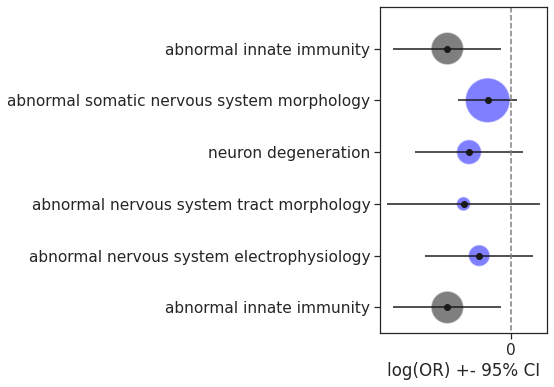

In [31]:
plt.figure(figsize=(3,6))

plt.errorbar(root_KO_df.loc[terms_plot]['log_OR'],np.arange(len(terms_plot)),
            xerr=[np.subtract(root_KO_df.loc[terms_plot]['log_OR'],root_KO_df.loc[terms_plot]['log_OR_CI_lower']),
                   np.subtract(root_KO_df.loc[terms_plot]['log_OR_CI_upper'],root_KO_df.loc[terms_plot]['log_OR'])],color='k',fmt='o')

color_temp = root_KO_df.loc[terms_plot]['MPO_term_type'].map({'brain':'blue','heart':'red','neg_ctrl':'black'})

sns.scatterplot(x=root_KO_df.loc[terms_plot]['log_OR'],
                y=np.arange(len(terms_plot)),size=root_KO_df.loc[terms_plot]['num_genes_in_term'],sizes=(200, 2000),
                alpha=.5,
               hue=color_temp.tolist(),palette={'blue':'blue','red':'red','black':'black'},legend=False)

plt.yticks(np.arange(len(terms_plot)),root_KO_df.loc[terms_plot]['MP_description'])
plt.xticks([0,1,2])
plt.xlabel('log(OR) +- 95% CI')

plt.plot([0,0],[-.8,len(terms_plot)-.5],'--',color='gray')
plt.ylim([-0.8,len(terms_plot)-.5])

plt.gca().invert_yaxis()


## 18. Compute the enrichment of phenotype(s) in NetColoc subsystems.

Some phenotypes may have stronger associations with NetColoc subsystems than with the root node. In this step we calculate the enrichment of selected phenotypes in each NetColoc subsystem.


In [32]:
MP_focal_top = root_KO_df.head(10).index.tolist() # record the top 10 overall
MP_full_results_df = validation.MPO_enrichment_full(hier_df,MPO,mgi_df,MP_focal_top,G_int)
MP_full_results_df.head()

abnormal innate immunity
Genes and Terms to keep: 68
abnormal pyramidal neuron dendrite morphology
Genes and Terms to keep: 2
abnormal olfactory sensory neuron morphology
Genes and Terms to keep: 3
abnormal postsynaptic density morphology
abnormal synaptic vesicle clustering
abnormal olfactory neuron innervation pattern
abnormal somatic nervous system morphology
Genes and Terms to keep: 375
neuron degeneration
Genes and Terms to keep: 14
neuronal cytoplasmic inclusions
abnormal synaptic neurotransmitter level


,abnormal innate immunity:-log(OR_p),abnormal innate immunity:log_OR,abnormal innate immunity:num_genes,abnormal innate immunity:gene_ids,abnormal pyramidal neuron dendrite morphology:-log(OR_p),abnormal pyramidal neuron dendrite morphology:log_OR,abnormal pyramidal neuron dendrite morphology:num_genes,abnormal pyramidal neuron dendrite morphology:gene_ids,abnormal olfactory sensory neuron morphology:-log(OR_p),abnormal olfactory sensory neuron morphology:log_OR,...,neuron degeneration:num_genes,neuron degeneration:gene_ids,neuronal cytoplasmic inclusions:-log(OR_p),neuronal cytoplasmic inclusions:log_OR,neuronal cytoplasmic inclusions:num_genes,neuronal cytoplasmic inclusions:gene_ids,abnormal synaptic neurotransmitter level:-log(OR_p),abnormal synaptic neurotransmitter level:log_OR,abnormal synaptic neurotransmitter level:num_genes,abnormal synaptic neurotransmitter level:gene_ids
C361,1.688719,-1.168836,4,FLOT1 GSDMD IER3 TMEM106A,1.401293,1.520348,2,CSMD3 LRFN2,1.103220,1.288228,...,4,CLN8 CLP1 CNTNAP4 RB1,0.869261,1.562653,1,PINK1,0.869261,1.562653,1,ATP1A2
C362,0.977679,-0.818806,4,FLOT1 GSDMD IER3 TMEM106A,0.568828,1.128226,1,CSMD3,0.426721,0.904766,...,3,CLN8 CLP1 RB1,1.166990,1.909069,1,PINK1,1.166990,1.909069,1,ATP1A2
C363,-0.000000,0.000000,0,,5.008511,3.308455,2,CSMD3 LRFN2,1.642647,2.332979,...,1,CNTNAP4,-0.000000,0.000000,0,,-0.000000,0.000000,0,
C364,-0.000000,0.000000,0,,-0.000000,0.000000,0,,-0.000000,0.000000,...,0,,-0.000000,0.000000,0,,-0.000000,0.000000,0,
C372,-0.000000,0.000000,0,,-0.000000,0.000000,0,,-0.000000,0.000000,...,0,,-0.000000,0.000000,0,,-0.000000,0.000000,0,


In [33]:
print("Top ten terms:")
print("\n".join([mp+" - "+get_MP_description(mp) for mp in MP_focal_top]))

Top ten terms:
MP:0002419 - abnormal innate immunity
MP:0020337 - abnormal pyramidal neuron dendrite morphology
MP:0006092 - abnormal olfactory sensory neuron morphology
MP:0020551 - abnormal postsynaptic density morphology
MP:0004793 - abnormal synaptic vesicle clustering
MP:0012014 - abnormal olfactory neuron innervation pattern
MP:0002752 - abnormal somatic nervous system morphology
MP:0003224 - neuron degeneration
MP:0011975 - neuronal cytoplasmic inclusions
MP:0002204 - abnormal synaptic neurotransmitter level


## 19. Annotate the NetColoc systems map with mouse variant data, input genes, and enriched GO terms

In [34]:
##save the systems map to upload in cross-species...
hier_df.to_csv('/proj/snic2022-6-229/private/Darwin_Affy/NEW_DA_IMP_MERGED/2024-02-08/netcoloc/CrossSpeciesBMI/Data/output/OCD_ONLY_systems_map.txt', sep="\t")
hier_df.head()

,CD_MemberList,CD_MemberList_Size,CD_Labeled,CD_MemberList_LogSize,CD_CommunityName,CD_AnnotatedMembers,CD_AnnotatedMembers_Size,CD_AnnotatedMembers_Overlap,CD_AnnotatedMembers_Pvalue,HiDeF_persistence,represents,name,system_ID,num_d1_seeds,frac_d1_seeds,frac_no_seeds
name,,,,,,,,,,,,,,,,
C361,ZNF804B DNAJA2 ING5 EED ATP1A2 TMEM80 ACACA RG...,361,False,8.496,,,0,0.0,0.0,0,C361,C361,0,48,0.132964,0.867036
C362,NCKIPSD ZNF804B DNAJA2 ITPKC ING5 H3-3B TMEM10...,257,False,8.006,,,0,0.0,0.0,137,C362,C362,1,41,0.159533,0.840467
C363,THAP9 PARM1 ZNF804B AGAP7P LRFN2 APBB3 PGBD4 L...,63,False,5.977,,,0,0.0,0.0,8,C363,C363,2,5,0.079365,0.920635
C364,ZNF232 ZKSCAN4 ZSCAN16 C5orf63 ZNF804A LRRC61 ...,61,False,5.931,,,0,0.0,0.0,101,C364,C364,3,4,0.065574,0.934426
C372,THAP9 ZNF804A PGBD4 SPINDOC TMEM161B ZSCAN31 G...,24,False,4.585,,,0,0.0,0.0,9,C372,C372,4,2,0.083333,0.916667


In [35]:
# add the best gprofiler annotation
MP_full_results_df['gprofiler_name']=pd.Series(system_name_list,index=hier_df.index.tolist())
# don't annotate the root node
root_node = hier_df['CD_MemberList_Size'].sort_values(ascending=False).head(1).index.tolist()[0]
MP_full_results_df.loc[root_node, 'gprofiler_name']=d1_name+'-'' systems map'

# also add the frac_seeds/num_seeds data here
MP_full_results_df=MP_full_results_df.join(hier_df[['num_d1_seeds','frac_d1_seeds','frac_no_seeds']],
                                          how='left')

MP_full_results_df.head()

,abnormal innate immunity:-log(OR_p),abnormal innate immunity:log_OR,abnormal innate immunity:num_genes,abnormal innate immunity:gene_ids,abnormal pyramidal neuron dendrite morphology:-log(OR_p),abnormal pyramidal neuron dendrite morphology:log_OR,abnormal pyramidal neuron dendrite morphology:num_genes,abnormal pyramidal neuron dendrite morphology:gene_ids,abnormal olfactory sensory neuron morphology:-log(OR_p),abnormal olfactory sensory neuron morphology:log_OR,...,neuronal cytoplasmic inclusions:num_genes,neuronal cytoplasmic inclusions:gene_ids,abnormal synaptic neurotransmitter level:-log(OR_p),abnormal synaptic neurotransmitter level:log_OR,abnormal synaptic neurotransmitter level:num_genes,abnormal synaptic neurotransmitter level:gene_ids,gprofiler_name,num_d1_seeds,frac_d1_seeds,frac_no_seeds
C361,1.688719,-1.168836,4,FLOT1 GSDMD IER3 TMEM106A,1.401293,1.520348,2,CSMD3 LRFN2,1.103220,1.288228,...,1,PINK1,0.869261,1.562653,1,ATP1A2,OCD- systems map,48,0.132964,0.867036
C362,0.977679,-0.818806,4,FLOT1 GSDMD IER3 TMEM106A,0.568828,1.128226,1,CSMD3,0.426721,0.904766,...,1,PINK1,1.166990,1.909069,1,ATP1A2,C362,41,0.159533,0.840467
C363,-0.000000,0.000000,0,,5.008511,3.308455,2,CSMD3 LRFN2,1.642647,2.332979,...,0,,-0.000000,0.000000,0,,C363,5,0.079365,0.920635
C364,-0.000000,0.000000,0,,-0.000000,0.000000,0,,-0.000000,0.000000,...,0,,-0.000000,0.000000,0,,C364,4,0.065574,0.934426
C372,-0.000000,0.000000,0,,-0.000000,0.000000,0,,-0.000000,0.000000,...,0,,-0.000000,0.000000,0,,C372,2,0.083333,0.916667


## 20. Export the NetColoc systems map to NDEx, with default style. 

Default style maps the fraction of seed genes from input set 1 (red) and input set 2 (blue) to node pie charts. The fraction of genes in each system that are in neither input set, but that are implicated by the network propagation are indicated in white.

In [36]:
# Convert G_hier to nice cx network
node_id_to_node_name = nx.get_node_attributes(G_hier, 'name')
for node_id in list(G_hier.nodes):
    del G_hier.nodes[node_id]['name']

G_hier_cx = ndex2.create_nice_cx_from_networkx(G_hier)

for node_id, node in G_hier_cx.get_nodes():
    node['n'] = node_id_to_node_name[node_id]

G_hier_cx.set_name(d1_name+'_systems_map') 
for node_id, node in G_hier_cx.get_nodes():
    data = MP_full_results_df.loc[node['r']]
    for row, value in data.items():
        if (row.find('gene_ids')>-1) or (row=='gprofiler_name'):
            data_type = "string"
            value=str(value)
        else:
            data_type = "double"
            value = str(value) # nice cx can only accept strings as values...
            if value=='inf': # check if inf, set to -1 if so
                value='-1'
            
        G_hier_cx.set_node_attribute(node_id, row, value, type=data_type)

# Restore some hierarchy properties to their state before networkx conversion.
for node_id, node in G_hier_cx.get_nodes():
    for i in np.arange(len(G_hier_cx.nodeAttributes[node_id])):
        dict_temp = G_hier_cx.nodeAttributes[node_id][i]
        if dict_temp['n'] in ['CD_MemberList_Size','CD_MemberList_LogSize','HiDeF_persistence']:
            G_hier_cx.set_node_attribute(node_id, dict_temp['n'], dict_temp['v'], type='double',overwrite=True)
            
# this is required so we can easily make subgraphs from systems
G_hier_cx.set_network_attribute('__CD_OriginalNetwork',
                                       values='0', type='long')
            
          
# use apply_style_from_network-- this should overwrite the existing style
netcoloc_template = ndex2.create_nice_cx_from_server('ndexbio.org',
            uuid='f338dea0-117c-11ec-9e8e-0ac135e8bacf')
G_hier_cx.apply_style_from_network(netcoloc_template)

In [37]:
#Upload to NDEx. Enter your ndex username and password. 
# If you are new to ndex, make a new account on the website (ndexbio.org)
G_hier_cx.set_name(d1_name+'_systems_map') 
SERVER = input('NDEx server (probably ndexbio.org): ')
USERNAME = input('NDEx user name: ')
PASSWORD = getpass.getpass('NDEx password: ')
network_uuid_hier = G_hier_cx.upload_to(SERVER, USERNAME, PASSWORD)

Generating CX


## 21. Apply another template style to NetColoc systems map for mouse knockout view, and export to NDEx. 

Select the property to be mapped to system node colors (should be one of the mouse knockout phenotypes we identified above). In this style, the log odds ratio is mapped to the system node color. Systems which are not significantly enriched for the phenotype are white (p<0.05).


In [38]:
# ------ modify this based on your project. Should be a system identified above -----
# set the property we should map to system node colors
mouse_KO_mapping_property = 'abnormal neuron morphology'

In [39]:
# apply a template style 
G_hier_cx.set_name(d1_name+'_systems_map_mouse_KO:'+mouse_KO_mapping_property) 
# use apply_style_from_network-- this should overwrite existing style
netcoloc_template = ndex2.create_nice_cx_from_server('ndexbio.org',
            uuid='4958993c-df46-11eb-b666-0ac135e8bacf')
raw_cx_st = json.dumps(netcoloc_template.to_cx())

# replace the default template values with mouse_KO_mapping_property
updated_raw_cx = re.sub('COL=abnormal heart development:log_OR', 'COL='+mouse_KO_mapping_property+':log_OR', raw_cx_st)
updated_raw_cx = re.sub('COL=abnormal heart development:-log', 
                        'COL='+mouse_KO_mapping_property+':-log', updated_raw_cx)
updated_raw_cx=json.loads(updated_raw_cx)
netcoloc_template_updated = ndex2.create_nice_cx_from_raw_cx(updated_raw_cx)
G_hier_cx.apply_style_from_network(netcoloc_template_updated)

network_uuid_hier_mouse_KO = G_hier_cx.upload_to(SERVER, USERNAME, PASSWORD)

Generating CX
Generating CX


## 22. Add genes associated with mouse variant phenotypes to NetColoc subnetwork, export to NDEx. 

In [40]:
# add fields to node_df for genes in each mouse_KO phenotype of interest
MP_genes_columns = [c for c in MP_full_results_df.columns.tolist() if c.find(':gene_ids')>-1]

# look up overlapping genes in the root node, add them to node_df
for MP in MP_genes_columns:
    focal_genes = MP_full_results_df.loc[root_node, MP].split(' ')
    node_df[MP]=0
    node_df.loc[focal_genes, MP]=1
node_df.head()

,d1_seeds,d1_name,z_d1,sum_seeds,abnormal innate immunity:gene_ids,abnormal pyramidal neuron dendrite morphology:gene_ids,abnormal olfactory sensory neuron morphology:gene_ids,abnormal postsynaptic density morphology:gene_ids,abnormal synaptic vesicle clustering:gene_ids,abnormal olfactory neuron innervation pattern:gene_ids,abnormal somatic nervous system morphology:gene_ids,neuron degeneration:gene_ids,neuronal cytoplasmic inclusions:gene_ids,abnormal synaptic neurotransmitter level:gene_ids
TUBB,1,OCD,22.379769,1,0,0,0,0,0,0,0,0,0,0
PABPC1L,1,OCD,21.400359,1,0,0,0,0,0,0,0,0,0,0
FLOT1,1,OCD,19.031443,1,1,0,0,0,0,0,0,0,0,0
ATP5MC1,1,OCD,18.392037,1,0,0,0,0,0,0,0,0,0,0
MAIP1,1,OCD,17.415480,1,0,0,0,0,0,0,0,0,0,0


In [41]:

G_prox_cx = ndex2.create_nice_cx_from_networkx(G_prox)
G_prox_cx.set_name(d1_name+'_NetColoc_subgraph') 
for node_id, node in G_prox_cx.get_nodes():
    data = node_df.loc[node['n']]
    for row, value in data.items():
        if row == 'd1_seeds' or row == 'd2_seeds' or row=='sum_seeds':
            data_type = 'double'
        elif row=='d1_name' or row=='d2_name':
            data_type='string'
        else:
            data_type = 'double'
        G_prox_cx.set_node_attribute(node_id, row, value, type=data_type)

# apply a template style (834b6ad4-d2ea-11eb-b666-0ac135e8bacf)
G_prox_cx.apply_template('ndexbio.org','834b6ad4-d2ea-11eb-b666-0ac135e8bacf')

network_uuid_NetColoc = G_prox_cx.upload_to(SERVER, USERNAME, PASSWORD)

Generating CX


## 23. Upload cosine-similarity transformed NetColoc subnetwork to NDEx

In [42]:
#Annotate network
print("Number of nodes in cosine similarity network:", len(G_cosSim.nodes()))
print("Number of edges in cosine similarity network:", len(G_cosSim.edges()))
G_cosSim_cx = ndex2.create_nice_cx_from_networkx(G_cosSim)
G_cosSim_cx.set_name(d1_name+'_NetColoc_subgraph_CosSim95') 
for node_id, node in G_cosSim_cx.get_nodes():
    data = node_df.loc[node['n']]
    for row, value in data.items():
        if row == 'd1_seeds' or row == 'd2_seeds' or row=='sum_seeds':
            data_type = 'double'
        elif row=='d1_name' or row=='d2_name':
            data_type='string'
        else:
            data_type = 'double'
        G_cosSim_cx.set_node_attribute(node_id, row, value, type=data_type)
        
        

# apply a template style (834b6ad4-d2ea-11eb-b666-0ac135e8bacf)
G_cosSim_cx.apply_template('ndexbio.org','2cbed84b-e5c3-11eb-b666-0ac135e8bacf')

network_uuid_NetColoc_CosSim = G_cosSim_cx.upload_to(SERVER, USERNAME, PASSWORD)

Number of nodes in cosine similarity network: 361
Number of edges in cosine similarity network: 2482
Generating CX


## 24. Add 4 networks from above to network set

In [43]:
# append the datestring to the network set to guarantee uniqueness
datestr = str(datetime.now())
networkSetURL=ndex2.client.Ndex2(host=SERVER,username=USERNAME,password=PASSWORD).create_networkset(d1_name+' network set: '+datestr,'network set for '+d1_name+' NetColoc subgraph and systems map')
networkSetURL

'https://www.ndexbio.org/v2/networkset/e27a025d-bbca-11f0-a218-005056ae3c32'

In [44]:
# parse out UUID from URL strings
networkSetUUID = networkSetURL.split('/')[-1]
networkSetUUID

networkURLs = [network_uuid_NetColoc,network_uuid_NetColoc_CosSim,network_uuid_hier,network_uuid_hier_mouse_KO]
networkUUIDs = [n.split('/')[-1] for n in networkURLs]

ndex2.client.Ndex2(host=SERVER,username=USERNAME,password=PASSWORD).add_networks_to_networkset(networkSetUUID,
                                                                                              networkUUIDs)


'https://www.ndexbio.org/v2/networkset/e27a025d-bbca-11f0-a218-005056ae3c32/members'